In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd
from scipy.io import arff
import statistics

In [2]:
# Utilities

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
    
        return cost.mean()

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        n = w_in.shape
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

In [3]:
train_data, meta = arff.loadarff('KDDTrain+.arff')
df = pd.DataFrame(train_data)
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
for col in ['protocol_type', 'service', 'flag', 'class']:
    df[col] = df[col].astype('category').cat.codes

In [4]:
# split training data into X and Y
# Isolating some categories that don't need encoding or cleaning
# n-feature isolated picture to demonstrate the difference in scaled and non-scaled features
# and gain experience plotting
train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)

print(train_X[:5])
print(train_y[:5])
print(train_X.shape, train_X.dtype)      # expect (~125973, 2) and float64
print(train_y.shape, train_y.dtype)

[[0.000e+00 1.000e+00 2.000e+01 9.000e+00 4.910e+02 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 2.000e+00 2.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e+00 0.000e+00 0.000e+00 1.500e+02 2.500e+01 1.700e-01 3.000e-02
  1.700e-01 0.000e+00 0.000e+00 0.000e+00 5.000e-02 0.000e+00]
 [0.000e+00 2.000e+00 4.400e+01 9.000e+00 1.460e+02 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 1.300e+01 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  8.000e-02 1.500e-01 0.000e+00 2.550e+02 1.000e+00 0.000e+00 6.000e-01
  8.800e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.000e+00 4.900e+01 5.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+0

In [8]:
# Fit n-feature training data to model!
# init weights and biases...
w_in = np.random.random_sample(train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 2000
#scaled_train_X = (train_X - train_X.mean(axis=0)) / train_X.std(axis=0)
scaled_train_X = train_X
stdevs = train_X.std(axis=0)
stdevs = np.clip(stdevs, 1e-7, None)
scaled_train_X = (train_X - train_X.mean(axis=0)) / stdevs
scaled_train_X[4:6] = np.log1p(train_X[4:6])

print(w_in)
print(b_in)
#print(scaled_train_X[0])
# print(np.ptp(scaled_train_X, axis=0))
# print(scaled_train_X[:5])
#plt.plot(np.zeros_like(scaled_train_X), scaled_train_X, 'x')
#plt.show()

[0.97996359 0.23041274 0.48719559 0.47041444 0.18617491 0.98317609
 0.9095722  0.4953428  0.15086493 0.35611467 0.45005523 0.19237735
 0.7941912  0.56677989 0.71562767 0.24795541 0.97466664 0.40278823
 0.14385023 0.96767652 0.79908941 0.20743754 0.38114919 0.16311097
 0.22011185 0.73525373 0.23093629 0.06433571 0.61972167 0.15223274
 0.25907482 0.37190154 0.80498631 0.6252541  0.50081431 0.2298416
 0.16085188 0.52755893 0.73590224 0.30556067 0.6789777 ]
0.7361149893415321


In [9]:
#w,b,J_history = gradient_descent(train_X, train_y, w_in, b_in, alpha, iters)
#print(f"New weights: {w}, new bias: {b}")

# The above code does not work!
# Since there are unscaled pieces of data (which are in the thousands)
# Predictions being fed into sigmoid (X[i]@w + b)
# are so large. Coupled with exp() being... exponential, overflow is inevitable
# So, scaling is not just for better results, it is impossible not to scale!

In [10]:
w,b,J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters)
print(f"New weights: {w}, new bias: {b}")

Iteration    0: Cost 1.0107983220068266
Iteration  200: Cost 0.16022566613559966
Iteration  400: Cost 0.14426721391159514
Iteration  600: Cost 0.13788993932493818
Iteration  800: Cost 0.13213643952265788
Iteration 1000: Cost 0.12926673329903726
Iteration 1200: Cost 0.1275375066570969
Iteration 1400: Cost 0.12626815821931156
Iteration 1600: Cost 0.12521544990521827
Iteration 1800: Cost 0.12428148394160698
New weights: [ 0.02239751  0.71951595  0.00146797  0.43345047 -0.07769359  0.13246555
  0.06431704 -0.7085022  -0.01471575 -0.60145978 -0.04225747  0.18706389
  0.74354661 -0.10835042  0.69552117  0.26083342  0.70630866 -0.02279319
  0.06866837  0.96767652  0.8008251   0.4366734  -0.67668459 -0.15673458
 -0.68510201 -0.31910151 -0.00266435 -0.36228231  1.20620157  0.38849561
 -0.22132984 -0.59009241  1.18711872 -0.23891577 -0.1856804  -0.912962
 -0.26603448 -0.48572541 -0.43662925 -0.19986423  0.0970432 ], new bias: 0.11947635779221473


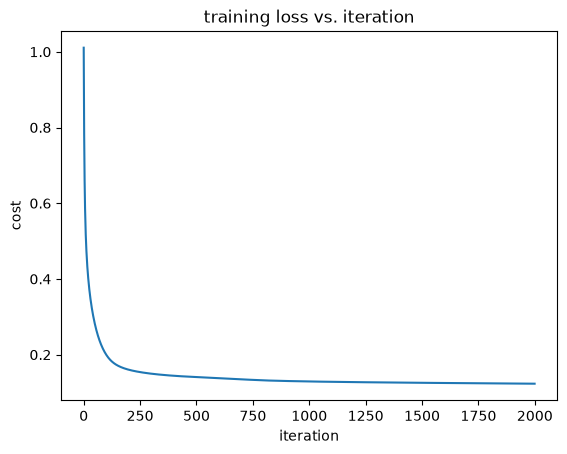

In [11]:
# plot cost vs. iterations
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("training loss vs. iteration")
plt.show()

In [12]:
preds = (sigmoid(train_X @ w + b) >= 0.5).astype(int)
print((preds == train_y).mean())

0.8383383740960364


In [13]:
# Displays proportion of dataset that is labeled normal and attack
print(train_y.mean())
print(1 - train_y.mean())

0.5345828074269883
0.46541719257301173


In [14]:
# Below is an education plot
# Assuming training on two features (any 2, but here src and dst bytes)
# Plots a scatter plot on src vs. dst bytes, points colour coded for attack or normal classification
# with decision boundary 
# x1 = scaled_train_X[:, 0]
# x2 = scaled_train_X[:, 1]

# plt.figure(figsize=(8, 6))

# y=train_y
# # scatter the two classes separately so they get different colours + a legend
# plt.scatter(x1[y == 0], x2[y == 0], s=5, alpha=0.3, label="normal")
# plt.scatter(x1[y == 1], x2[y == 1], s=5, alpha=0.3, label="attack")

# # the decision boundary: the line where w0*x1 + w1*x2 + b = 0
# # rearranged for x2:  x2 = -(w0*x1 + b) / w1
# xs = np.linspace(x1.min(), x1.max(), 200)
# boundary = -(w[0] * xs + b) / w[1]
# plt.plot(xs, boundary, color="black", linewidth=2, label="decision boundary")

# plt.xlabel("log src_bytes (scaled)")
# plt.ylabel("log dst_bytes (scaled)")
# plt.legend()
# plt.ylim(x2.min(), x2.max())   # keep the view on the data if the line shoots off
# plt.show()

In [15]:
# Get test inputs
test_data, test_meta = arff.loadarff('KDDTest+.arff')
test_df = pd.DataFrame(test_data)

for col in test_df.select_dtypes([object]):
        test_df[col] = test_df[col].str.decode('utf-8')
for col in ['protocol_type', 'service', 'flag', 'class']:
    test_df[col] = test_df[col].astype('category').cat.codes

test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

In [16]:
preds = (sigmoid(test_X @ w + b) >= 0.5).astype(int)
print((preds == test_y).mean())

0.7616217175301633
